## Sensibility

In [ ]:
import pandas as pd, numpy as np
import pickle, seaborn as sns
from matplotlib import pyplot as plt


data = pickle.load(open('../tsnh/diferent_persona_vectors.pickle', 'rb'))

personas = ["You are an expert in social psychology. When you are asked a question, you prefer to give short, concrete answers.",
"You are an expert in social psychology.",
"",
"You are a Linguist.",
"You are a content moderator.",
"You are a psychologist.",
"You are a social media expert.",
"You are a political scientist.",
"You are a sociologist.",]

## TSNH

In [ ]:

import pandas as pd, numpy as np
import pickle, seaborn as sns
from matplotlib import pyplot as plt


data = pickle.load(open('../tsnh/diferent_persona_vectors.pickle', 'rb'))
values_per_instance = np.array([np.array(data[i]['values']) for i in range(len(data))])

print(values_per_instance.shape)

from itertools import combinations
# from scipy.stats import spearmanr
from scipy.stats import pearsonr
import seaborn as sns

sample = values_per_instance.reshape(len(personas), -1)
pairs = list(combinations(range(len(sample)), 2))
corr_values_tsnh = np.zeros((len(sample), len(sample)))
# Perform pairwise Spearman tests
ps = np.zeros((len(sample), len(sample)))
for i, j in pairs:
    corr, p = pearsonr(sample[i], sample[j])
    corr_values_tsnh[i][j] = corr
    ps[i][j] = p
    print(f"Spearman correlation between LLM{i+1} and LLM{j+1}: {corr:.3f}, p-value: {p}")

## Germeval

In [ ]:

import pandas as pd, numpy as np
import pickle, seaborn as sns
from matplotlib import pyplot as plt

from itertools import combinations
from scipy.stats import pearsonr
import seaborn as sns

data = pickle.load(open('../germeval/diferent_persona_vectors_train.pickle', 'rb'))
values_per_instance = np.array([np.array(data[i]['values']) for i in range(len(data))])
print(values_per_instance.shape)


sample = values_per_instance.reshape(len(personas), -1)
pairs = list(combinations(range(len(sample)), 2))
corr_values_germ = np.zeros((len(sample), len(sample)))
# Perform pairwise Spearman tests
ps = np.zeros((len(sample), len(sample)))
for i, j in pairs:
    corr, p = pearsonr(sample[i], sample[j])
    corr_values_germ[i][j] = corr
    ps[i][j] = p
    print(f"Spearman correlation between LLM{i+1} and LLM{j+1}: {corr:.3f}, p-value: {p}")

In [ ]:
# corr_values_tsnh mean of the triangle superior
upper_triangle_indices = np.triu_indices_from(corr_values_germ, k=1)

# Extract the values of the superior triangle
superior_triangle_values = corr_values_germ[upper_triangle_indices]

# Compute the mean value of the superior triangle
np.mean(superior_triangle_values)


np.float64(0.9128527475334661)

/tmp/ipykernel_2799973/1386710111.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the color bar


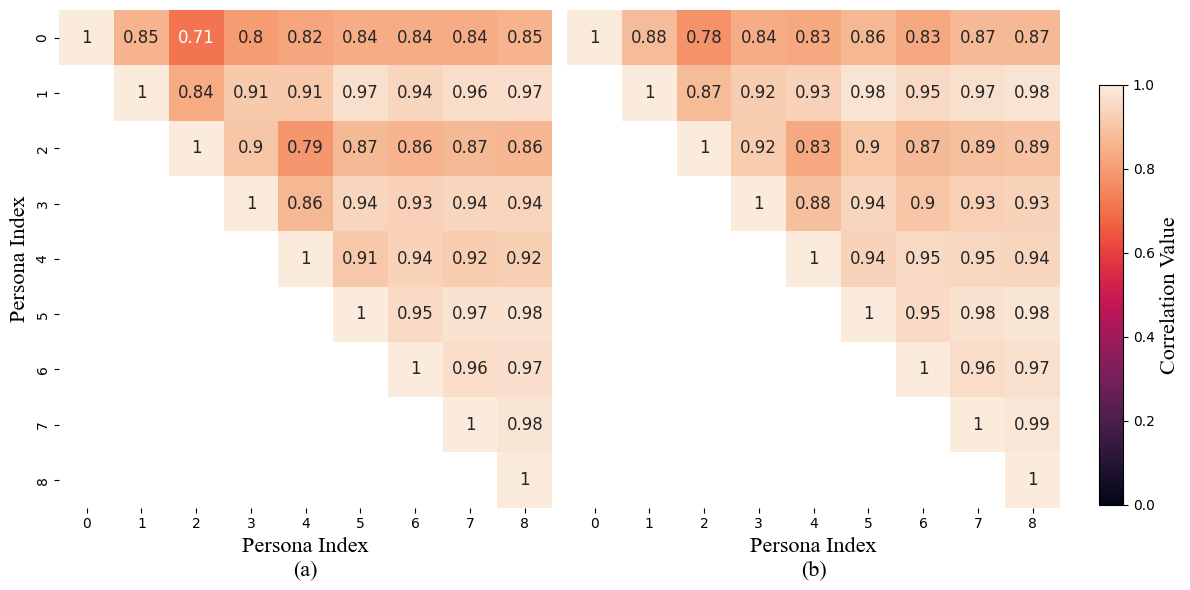

In [ ]:
# Mask the lower triangle
from matplotlib import rcParams


mask = np.triu(np.ones_like(corr_values_tsnh, dtype=bool))

# Determine global color limits
vmin = min(corr_values_tsnh.min(), corr_values_germ.min())
vmax = max(corr_values_tsnh.max(), corr_values_germ.max())

# Create subplots for the heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap for corr_values_tsnh
sns.heatmap(corr_values_tsnh, annot=True, cbar=False, 
            ax=axes[0], vmin=vmin, vmax=vmax, mask=~mask, cmap='rocket', 
    		annot_kws={'fontsize': 12})
axes[0].set_title('Correlation Matrix - TSNH')
axes[0].set_ylabel('Persona Index', fontsize=16, fontproperties=times_new_roman)
axes[0].set_xlabel('Persona Index\n(a)', fontsize=16, fontproperties=times_new_roman)

# Heatmap for corr_values_germeval
sns.heatmap(corr_values_germ, annot=True, cbar=False, ax=axes[1], 
            vmin=vmin, vmax=vmax, mask=~mask, cmap='rocket',
			annot_kws={'fontsize': 12})
axes[1].set_title('Correlation Matrix - Germeval', fontsize=12)
axes[1].set_xlabel('Persona Index\n(b)', fontsize=16, fontproperties=times_new_roman)
axes[1].set_ylabel('')  # Remove y-axis label
axes[1].tick_params(left=False)  # Remove y-axis ticks
axes[1].set_yticklabels([])

# Create a single global color bar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position: [left, bottom, width, height]
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap='rocket')
fig.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel('Correlation Value', fontsize=16, fontproperties=times_new_roman)

# Adjust layout and save the figure
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the color bar
plt.savefig('correlation_matrices.eps', dpi=600, format='eps')
plt.show()

## Train a logistic regression to see if values changes. (Germeval)
- why ? Because there is not random initializations and is fast to train :)

In [ ]:
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import pickle
import numpy as np
import pandas as pd

train_file_name = '../germeval/train.csv'
test_file_name = '../germeval/test.csv'

def get_mapping(data_transformation, persona):
     
	mapping_train = {data_transformation['train'][persona]['id'][i]:np.array(data_transformation['train'][persona]['values'][i]) for i in range(len(data_transformation['train'][persona]['id']))}
	mapping_test = {data_transformation['test'][persona]['id'][i]:np.array(data_transformation['test'][persona]['values'][i]) for i in range(len(data_transformation['test'][persona]['id']))}
	return mapping_train, mapping_test

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

data_transformation = {}
with open(f'../germeval/diferent_persona_vectors_train.pickle', 'rb') as handle:
	data_transformation['train'] = pickle.load(handle)
with open(f'../germeval/diferent_persona_vectors_test.pickle', 'rb') as handle:
	data_transformation['test'] = pickle.load(handle)	
      

df_test = pd.read_csv(test_file_name, sep=',')
df_train = pd.read_csv(train_file_name, sep=',')



mean_performance_personas_germeval = {'train':[],
						'test':[]}

for persona in range(9):

	feature_vectors_train = []
	labels_train = []

	feature_vectors_test = []
	labels_test = []

	mapping_train, mapping_test = get_mapping(data_transformation, persona)

	for _, row in df_train.iterrows():
		feature_vectors_train += [mapping_train[row['id']]]
		labels_train += [row['Class']]


	for _, row in df_test.iterrows():
		feature_vectors_test += [mapping_test[row['id']]]
		labels_test += [row['Class']]


	feature_vectors_train = np.array(feature_vectors_train)
	feature_vectors_test = np.array(feature_vectors_test)
	labels_train = np.array(labels_train)
	labels_test = np.array(labels_test)


	clf = LogisticRegression()
	clf.fit(feature_vectors_train, labels_train)
	mean_performance_personas_germeval['train'] += [evaluate(clf, feature_vectors_train, labels_train)]
	mean_performance_personas_germeval['test'] += [evaluate(clf, feature_vectors_test, labels_test)]

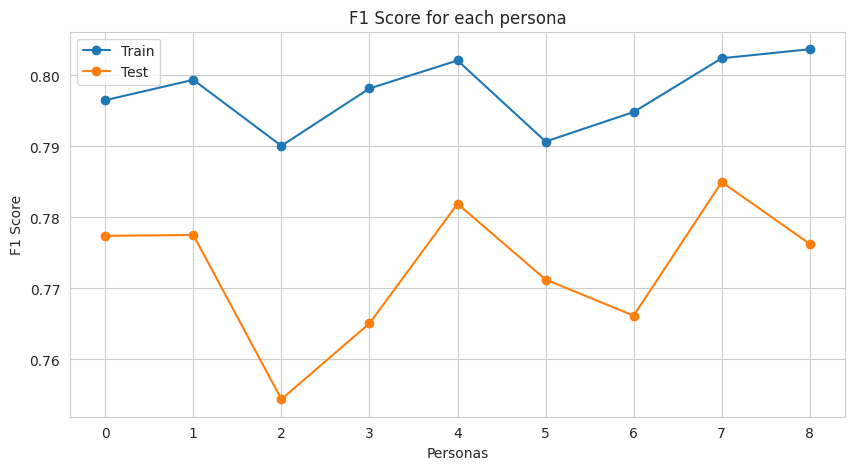

In [14]:
# plot values for train and test
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.figure(figsize=(10,5))
plt.plot(range(9), mean_performance_personas_germeval['train'], label='Train', marker='o')
plt.plot(range(9), mean_performance_personas_germeval['test'], label='Test', marker='o')
plt.legend()
plt.xlabel('Personas')
plt.ylabel('F1 Score')
# plt.ylim(0, 1)
plt.title('F1 Score for each persona')

plt.show()

## Train a logistic regression to see if values changes. (TSNH)

In [ ]:
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
import pickle
import numpy as np
import pandas as pd

file_name = '../tsnh/TSNH_uniform.csv'

def get_mapping(data_transformation, persona):
     
	mapping_train = {data_transformation[persona]['id'][i]:np.array(data_transformation[persona]['values'][i]) for i in range(len(data_transformation[persona]['id']))}
	return mapping_train

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

with open(f'../tsnh/diferent_persona_vectorstrain.csv.pickle', 'rb') as handle:
	data_transformation = pickle.load(handle)	

df_train = pd.read_csv(file_name, sep=',')
df_train = df_train.dropna()


performance_personas = {'train':np.zeros((9, 5)),
						'test':np.zeros((9, 5))}

skf = StratifiedKFold(n_splits=5, shuffle=True)

for i, (train_index, test_index) in enumerate(skf.split(np.arange(len(df_train)), df_train['Class'].values)):

	for persona in range(9):

		feature_vectors = []
		labels = []

		mapping_train = get_mapping(data_transformation, persona)
		mal = 0 
		for _, row in df_train.iterrows():
			feature_vectors += [mapping_train[row['id']]]
			labels += [row['Class']]
		
		feature_vectors = np.array(feature_vectors)
		labels = np.array(labels)

		clf = LogisticRegression()
		clf.fit(feature_vectors[train_index], labels[train_index])
		performance_personas['train'][persona, i] = evaluate(clf, feature_vectors[train_index], labels[train_index])
		performance_personas['test'][persona, i] = evaluate(clf, feature_vectors[test_index], labels[test_index])

In [6]:
mean_performance_personas_tsnh = {'train':np.mean(performance_personas['train'], axis=1),
						'test':np.mean(performance_personas['test'], axis=1)}
std_performance_personas_tsnh = {'train':np.std(performance_personas['train'], axis=1),
						'test':np.std(performance_personas['test'], axis=1)}


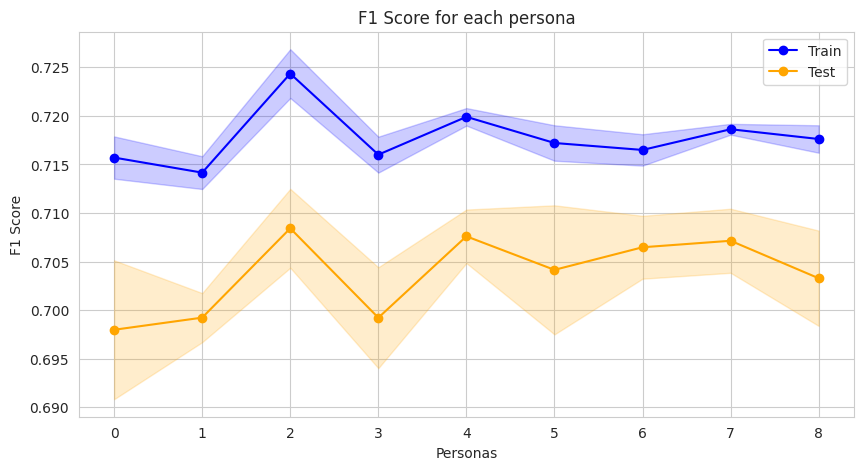

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming mean_performance_personas and std_performance_personas are predefined
sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))

x = range(9)  # Replace with appropriate x values if different

# Train plot with shaded std area
plt.plot(x, mean_performance_personas_tsnh['train'], label='Train', marker='o', color='blue')
plt.fill_between(x,
                 mean_performance_personas_tsnh['train'] - std_performance_personas_tsnh['train'],
                 mean_performance_personas_tsnh['train'] + std_performance_personas_tsnh['train'],
                 alpha=0.2, color='blue')

# Test plot with shaded std area
plt.plot(x, mean_performance_personas_tsnh['test'], label='Test', marker='o', color='orange')
plt.fill_between(x,
                 mean_performance_personas_tsnh['test'] - std_performance_personas_tsnh['test'],
                 mean_performance_personas_tsnh['test'] + std_performance_personas_tsnh['test'],
                 alpha=0.2, color='orange')


# plt.ylim(0, 1)
plt.legend()
plt.xlabel('Personas')
plt.ylabel('F1 Score')
plt.title('F1 Score for each persona')
plt.show()